In [1]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import copy
import numpy as np


In [13]:
class LogisticRegression(nn.Module):

    def __init__(self, p, batch_size=32, lr=1e-3, lr_type='constant', gamma=0.1, power=0.6, device=None):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.linear = nn.Linear(p, 1, bias=True).to(self.device)
        self.p = p
        self.batch_size = batch_size
        self.lr = lr
        self.lr_type = lr_type
        self.power = power
        self.gamma = gamma
        self.loss_history = []
        self.val_loss_history = []
        self.param_trajectory = []


    def forward(self, x):

        return self.linear(x).squeeze(-1)

    def predict_proba(self, x):

        x = x.to(self.device)
        with torch.no_grad():
            return torch.sigmoid(self.linear(x)).squeeze(-1).cpu()

    def predict(self, x):
        return (self.predict_proba(x)>0.5).float()

    def get_lr(self, n):

        if self.lr_type == 'constant':
            return self.lr

        elif self.lr_type == 'polynomial':
            return self.gamma/((n+1)**self.power)

        elif self.lr_type == 'inverse':

            return self.gamma/(n+1)
        else:
            return ValueError("Invalid learning rate schedule")

    def plot_loss(self):
        plt.figure()
        plt.plot(self.loss_history, label="Training Loss")

        if len(self.val_loss_history) > 0:
            plt.plot(self.val_loss_history, label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend(loc="upper right")
        plt.show()

    def fit(self, X, y, X_val=None, y_val=None, epochs=50, patience=5, tol=1e-4):

        X = X.to(self.device)
        y = y.to(self.device)

        if X_val is not None and y_val is not None:
            X_val = X_val.to(self.device)
            y_val = y_val.to(self.device)

        dataset = TensorDataset(X, y)
        loader =  DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.SGD(self.parameters(), lr=self.lr)

        best_loss = float("inf")
        best_state = None
        patience_counter = 0

        n = 0
        pbar = tqdm(range(epochs), desc="Training", leave=True)

        for epoch in pbar:

            self.train()
            epoch_loss = 0.0

            for xb, yb in loader:

                lr_n = self.get_lr(n)

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr_n

                optimizer.zero_grad()

                logits = self.forward(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            epoch_loss = epoch_loss / len(loader)
            self.loss_history.append(epoch_loss)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    val_logits = self(X_val)
                    val_loss = criterion(val_logits, y_val).item()
                    self.val_loss_history.append(val_loss)

                    if val_loss < best_loss -tol:
                        best_loss = val_loss
                        best_state = copy.deepcopy(self.state_dict())
                        patience_counter = 0
                    else:
                        patience_counter = patience_counter + 1

                if val_loss is not None:

                    pbar.set_postfix({"train_loss": f"{epoch_loss:.4f}",
                                      "val_loss": f"{val_loss:.4f}",
                                      "lr": f"{lr_n:.5f}",})

                else:

                    pbar.set_postfix({"train_loss": f"{epoch_loss:.4f}",
                                      "lr": f"{lr_n:.5f}"})

                if patience_counter >= patience:
                    pbar.set_postfix({"early_stopping": epoch})
                    break

            if best_state is not None:
                self.load_state_dict(best_state)








In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


seed = 10
N = 2000
D = 5
bias = 1.5
torch.manual_seed(seed)
# features
X = torch.randn(N, D)

# coeficientes
beta = torch.randn(D)

# modelo lineal con bias
logits = X @ beta + bias

# probabilidades
probs = torch.sigmoid(logits)

# etiquetas
y = torch.bernoulli(probs)

perm = torch.randperm(len(X))
train_idx = perm[:1500]
val_idx = perm[1500:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

In [25]:
model = LogisticRegression(p=5, device=device)
model.fit(X_train, y_train, X_val, y_val, epochs=100, patience=5, tol=1e-6)

Training: 100%|██████████| 100/100 [00:06<00:00, 15.75it/s, train_loss=0.4819, val_loss=0.5064, lr=0.00100]


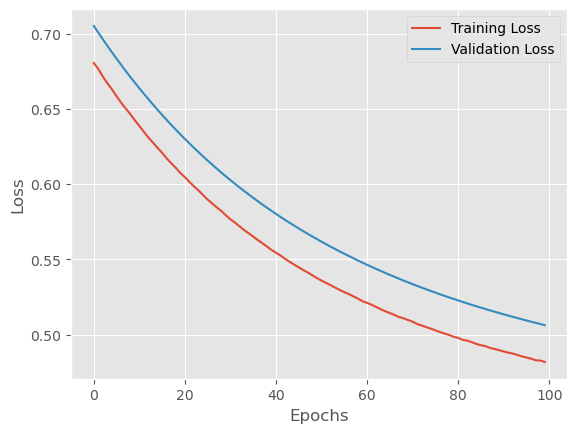

In [26]:
model.plot_loss()

In [28]:
model2 = LogisticRegression(p=5,lr_type="inverse" , device=device)
model2.fit(X_train, y_train, X_val, y_val, epochs=100, patience=5, tol=1e-6)

Training: 100%|██████████| 100/100 [00:06<00:00, 15.83it/s, train_loss=0.5868, val_loss=0.5673, lr=0.00002]


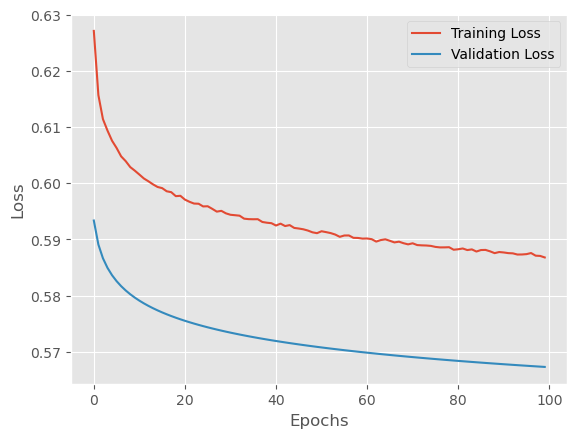

In [29]:
model2.plot_loss()

In [ ]:
#criterion = nn.PoissonNLLLoss(log_input=True)

#log_mu = model(X)   # η
#loss = criterion(log_mu, y)

#criterion = nn.PoissonNLLLoss(log_input=False)

#mu = torch.exp(model(X))
#loss = criterion(mu, y)

In [3]:
class GaussianLinearRegression(nn.Module):

    def __init__(self, p):
        super().__init__()

        self.linear = nn.Linear(p, 1)

        # parámetro libre
        self.log_sigma = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):

        mu = self.linear(x).squeeze(-1)

        sigma = torch.exp(self.log_sigma)

        return mu, sigma

In [4]:
def gaussian_nll(mu, y, sigma):

    return (
        0.5 * torch.log(2 * torch.pi * sigma**2)
        + 0.5 * ((y - mu)**2) / sigma**2
    ).mean()

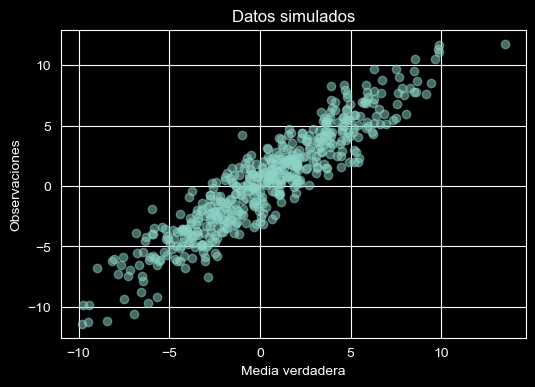

X shape: torch.Size([500, 3])
y shape: torch.Size([500])


In [5]:
N = 500
p = 3

# variables explicativas
X = torch.randn(N, p)

# parámetros verdaderos
beta_true = torch.tensor([2.5, -1.0, 3.0])

bias_true = 0.7

sigma_true = 1.5

# media verdadera
mu = X @ beta_true + bias_true

# ruido gaussiano
eps = sigma_true * torch.randn(N)

# variable respuesta
y = mu + eps

# =========================
# Visualización
# =========================

plt.figure(figsize=(6,4))

plt.scatter(mu.numpy(), y.numpy(), alpha=0.5)

plt.xlabel("Media verdadera")
plt.ylabel("Observaciones")

plt.title("Datos simulados")

plt.show()

# =========================
# Shapes
# =========================

print("X shape:", X.shape)
print("y shape:", y.shape)

In [10]:
model = GaussianLinearRegression(p=X.shape[1])

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

for epoch in range(3000):

    optimizer.zero_grad()

    mu, sigma = model(X)

    loss = gaussian_nll(mu, y, sigma)

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item(), sigma.item())

0 10.864148139953613 1.0
100 2.8088698387145996 3.843470335006714
200 2.7549872398376465 3.869140386581421
300 2.7013351917266846 3.699481725692749
400 2.643294334411621 3.5017831325531006
500 2.580287218093872 3.296520471572876
600 2.511840343475342 3.086858034133911
700 2.437641143798828 2.8743386268615723
800 2.357771158218384 2.6611640453338623
900 2.2731263637542725 2.4509057998657227
1000 2.186047315597534 2.2490642070770264
1100 2.1009650230407715 2.0633461475372314
1200 2.0243403911590576 1.902947187423706
1300 1.962783694267273 1.7760026454925537
1400 1.9196515083312988 1.6857448816299438
1500 1.8932405710220337 1.6284385919570923
1600 1.8787211179733276 1.595556378364563
1700 1.8712838888168335 1.5780876874923706
1800 1.8676220178604126 1.5692681074142456
1900 1.865854024887085 1.5649464130401611
2000 1.8650075197219849 1.5628619194030762
2100 1.8646036386489868 1.5618640184402466
2200 1.8644108772277832 1.5613877773284912
2300 1.864319086074829 1.5611604452133179
2400 1.8642

In [12]:
model.log_sigma.exp()

tensor(1.5610, grad_fn=<ExpBackward0>)

In [13]:
model.linear.weight


Parameter containing:
tensor([[ 2.5671, -1.0155,  2.9813]], requires_grad=True)

In [14]:
model.linear.bias

Parameter containing:
tensor([0.7975], requires_grad=True)